In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
import ast
load_dotenv()



True

In [ ]:
cummulative_diff=pd.read_csv(os.getenv("differentiation_cumulative")) 
question_metadata=pd.read_csv(os.getenv("QUESTION_METADATA_PATH"))
chronological_delta=pd.read_csv(os.getenv("chronological_delta_path"))

cummulative_diff=pd.merge(cummulative_diff,question_metadata,left_on='questions',right_on='index',how='left')

## Diffrentiation Analysis

<Figure size 1200x600 with 0 Axes>

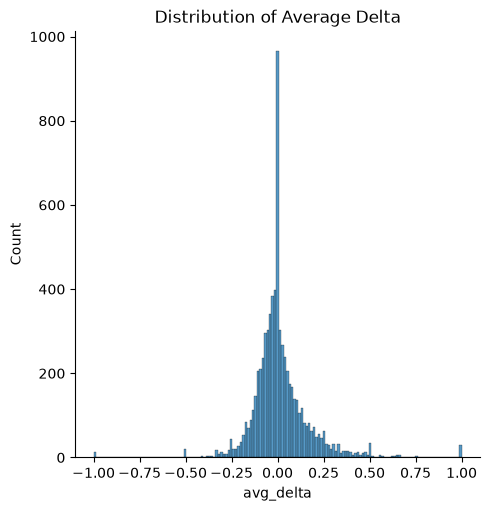

In [16]:

#distribution of avg_delta
plt.figure(figsize=(12,6))
sns.displot(cummulative_diff['avg_delta'],kind='hist')
plt.title('Distribution of Average Delta')
plt.show()



Number of rows with both avg_delta and median_delta not null: 7037


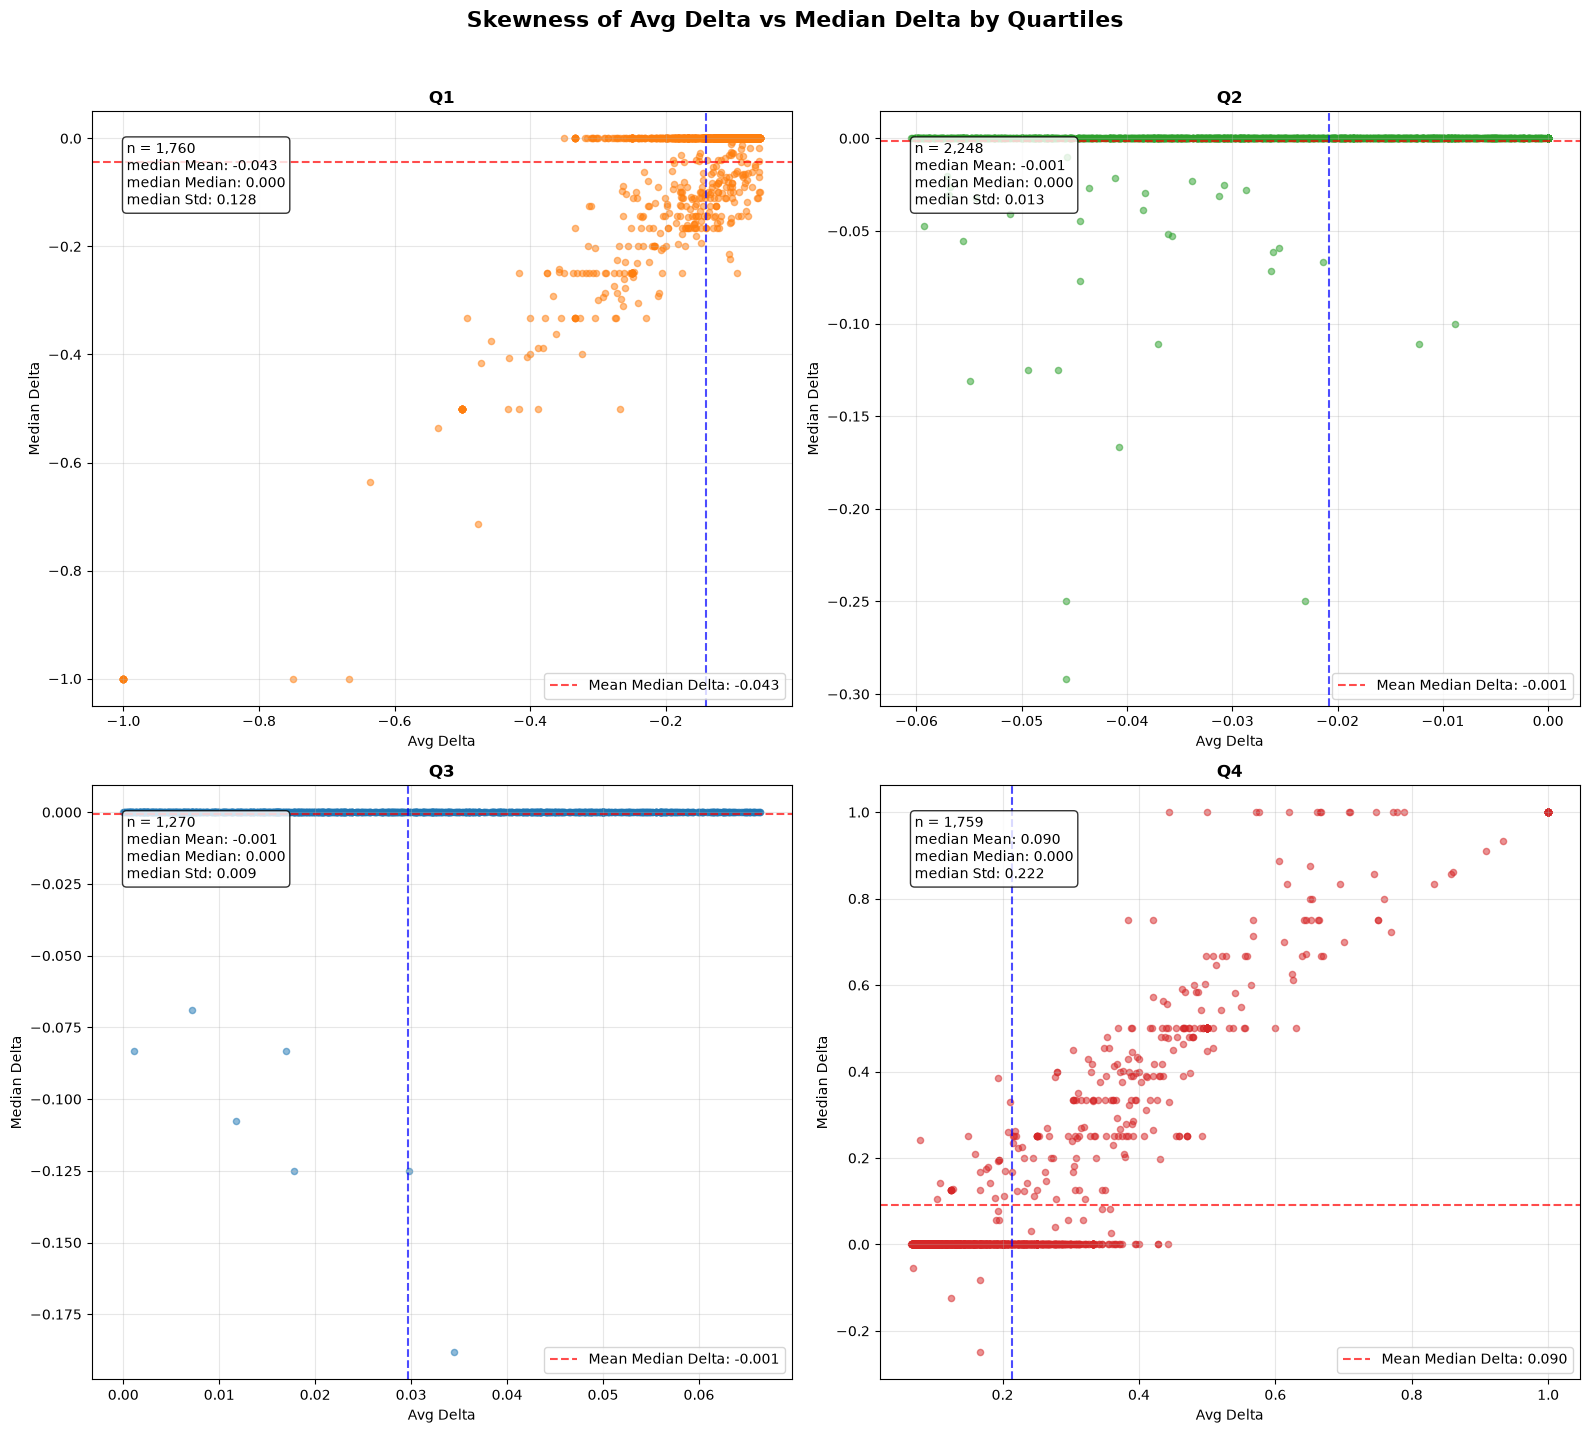

In [17]:
#avg_delta vs median delta
cummulative_diff['delta_quartile'] = pd.qcut(cummulative_diff['avg_delta'], 
                                      q=4, 
                                      labels=['Q1', 'Q2', 'Q3', 'Q4'])
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

df=cummulative_diff[cummulative_diff['avg_delta'].notnull() & cummulative_diff['median_delta'].notnull()]
print(f"Number of rows with both avg_delta and median_delta not null: {len(df)}")

# Color palette for each quartile
colors = ['#ff7f0e', '#2ca02c', '#1f77b4', '#d62728']
quartile_labels = ['Q1 (Lowest Delta)', 'Q2', 'Q3', 'Q4 (Highest Delta)']

for idx, (ax, quartile) in enumerate(zip(axes, sorted(df['delta_quartile'].unique()))):
    # Subset data
    subset = df[df['delta_quartile'] == quartile]
    
    # Scatter plot
    ax.scatter(subset['avg_delta'], subset['median_delta'], 
               alpha=0.5, s=20, color=colors[idx])
    
    # Add mean lines
    ax.axhline(y=subset['median_delta'].mean(), 
               color='red', linestyle='--', alpha=0.7, 
               label=f'Mean Median Delta: {subset["median_delta"].mean():.3f}')
    ax.axvline(x=subset['avg_delta'].mean(), 
               color='blue', linestyle='--', alpha=0.7)
    
    # Add statistics
    ax.text(0.05, 0.95, 
            f'n = {len(subset):,}\n'
            f'median Mean: {subset["median_delta"].mean():.3f}\n'
            f'median Median: {subset["median_delta"].median():.3f}\n'
            f'median Std: {subset["median_delta"].std():.3f}',
            transform=ax.transAxes,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title(f'{quartile}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Avg Delta')
    ax.set_ylabel('Median Delta')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right')

plt.suptitle('Skewness of Avg Delta vs Median Delta by Quartiles', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

0        37.751903
1        97.554348
2        98.894009
3        93.219814
5        97.981157
           ...    
7612    100.000000
7613    100.000000
7614    100.000000
7616    100.000000
7617    100.000000
Name: proportion_observations, Length: 7037, dtype: float64


C:\Users\Hatem\AppData\Local\Temp\ipykernel_22368\198335503.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['proportion_observations'] = ((df['n_observations'] / df['n_students'])*100.00).clip(upper=100)


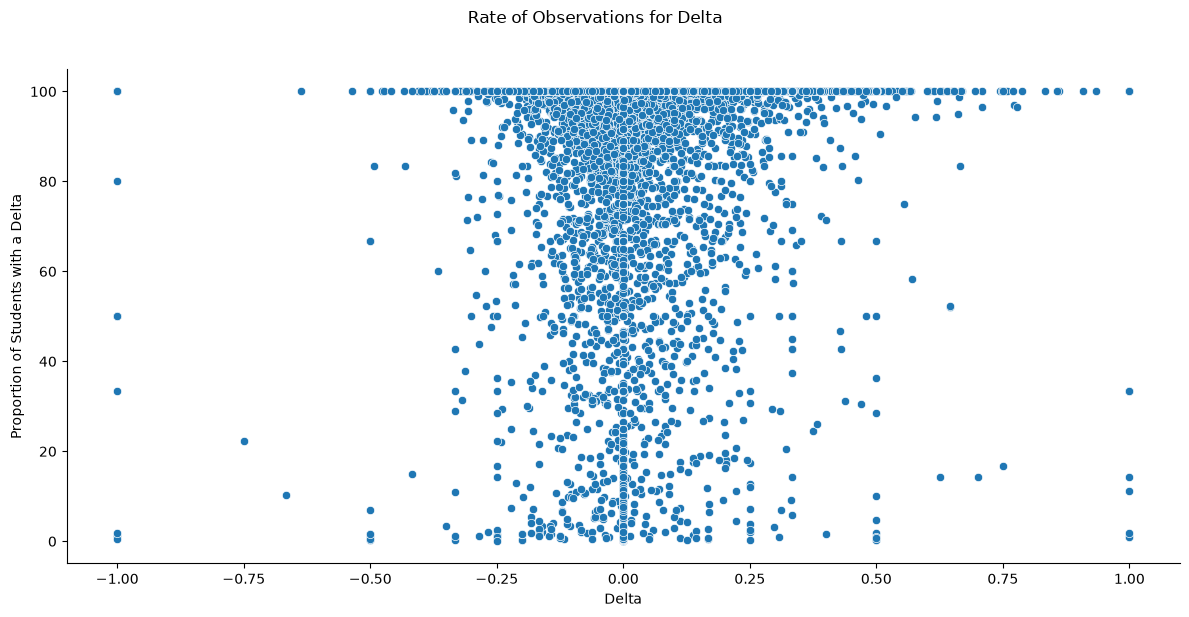

In [18]:
#check that n_observations increases steadily with n_students 
df['proportion_observations'] = ((df['n_observations'] / df['n_students'])*100.00).clip(upper=100)
print(df['proportion_observations'])
#plot the propotion of observations against the avg_delta
# relplot returns a FacetGrid object
g = sns.relplot(data=df, x='avg_delta', y='proportion_observations', 
                kind='scatter', height=6, aspect=2)

# Set labels using the FacetGrid methods
g.set_axis_labels('Delta', 'Proportion of Students with a Delta')
g.fig.suptitle('Rate of Observations for Delta', y=1.02)  # Add title to the figure

plt.tight_layout()
plt.show()


    improvement_rate improvement_quartile  avg_delta delta_quartile
0           0.202418                   Q3  -0.312805             Q1
1           0.038043                   Q2   0.200446             Q4
2           0.247005                   Q3  -0.069883             Q1
3           0.283637                   Q4  -0.152723             Q1
4           0.000000                   Q1        NaN            NaN
5           0.071332                   Q2   0.086615             Q4
6           0.176338                   Q3  -0.105147             Q1
7           0.060244                   Q2  -0.103837             Q1
8           0.109513                   Q2   0.032897             Q3
9           0.216129                   Q3  -0.101611             Q1
10          0.162162                   Q3  -0.009530             Q2
11          0.015845                   Q1   0.038251             Q3
12          0.223269                   Q3   0.000029             Q3
13          0.360862                   Q4  -0.02

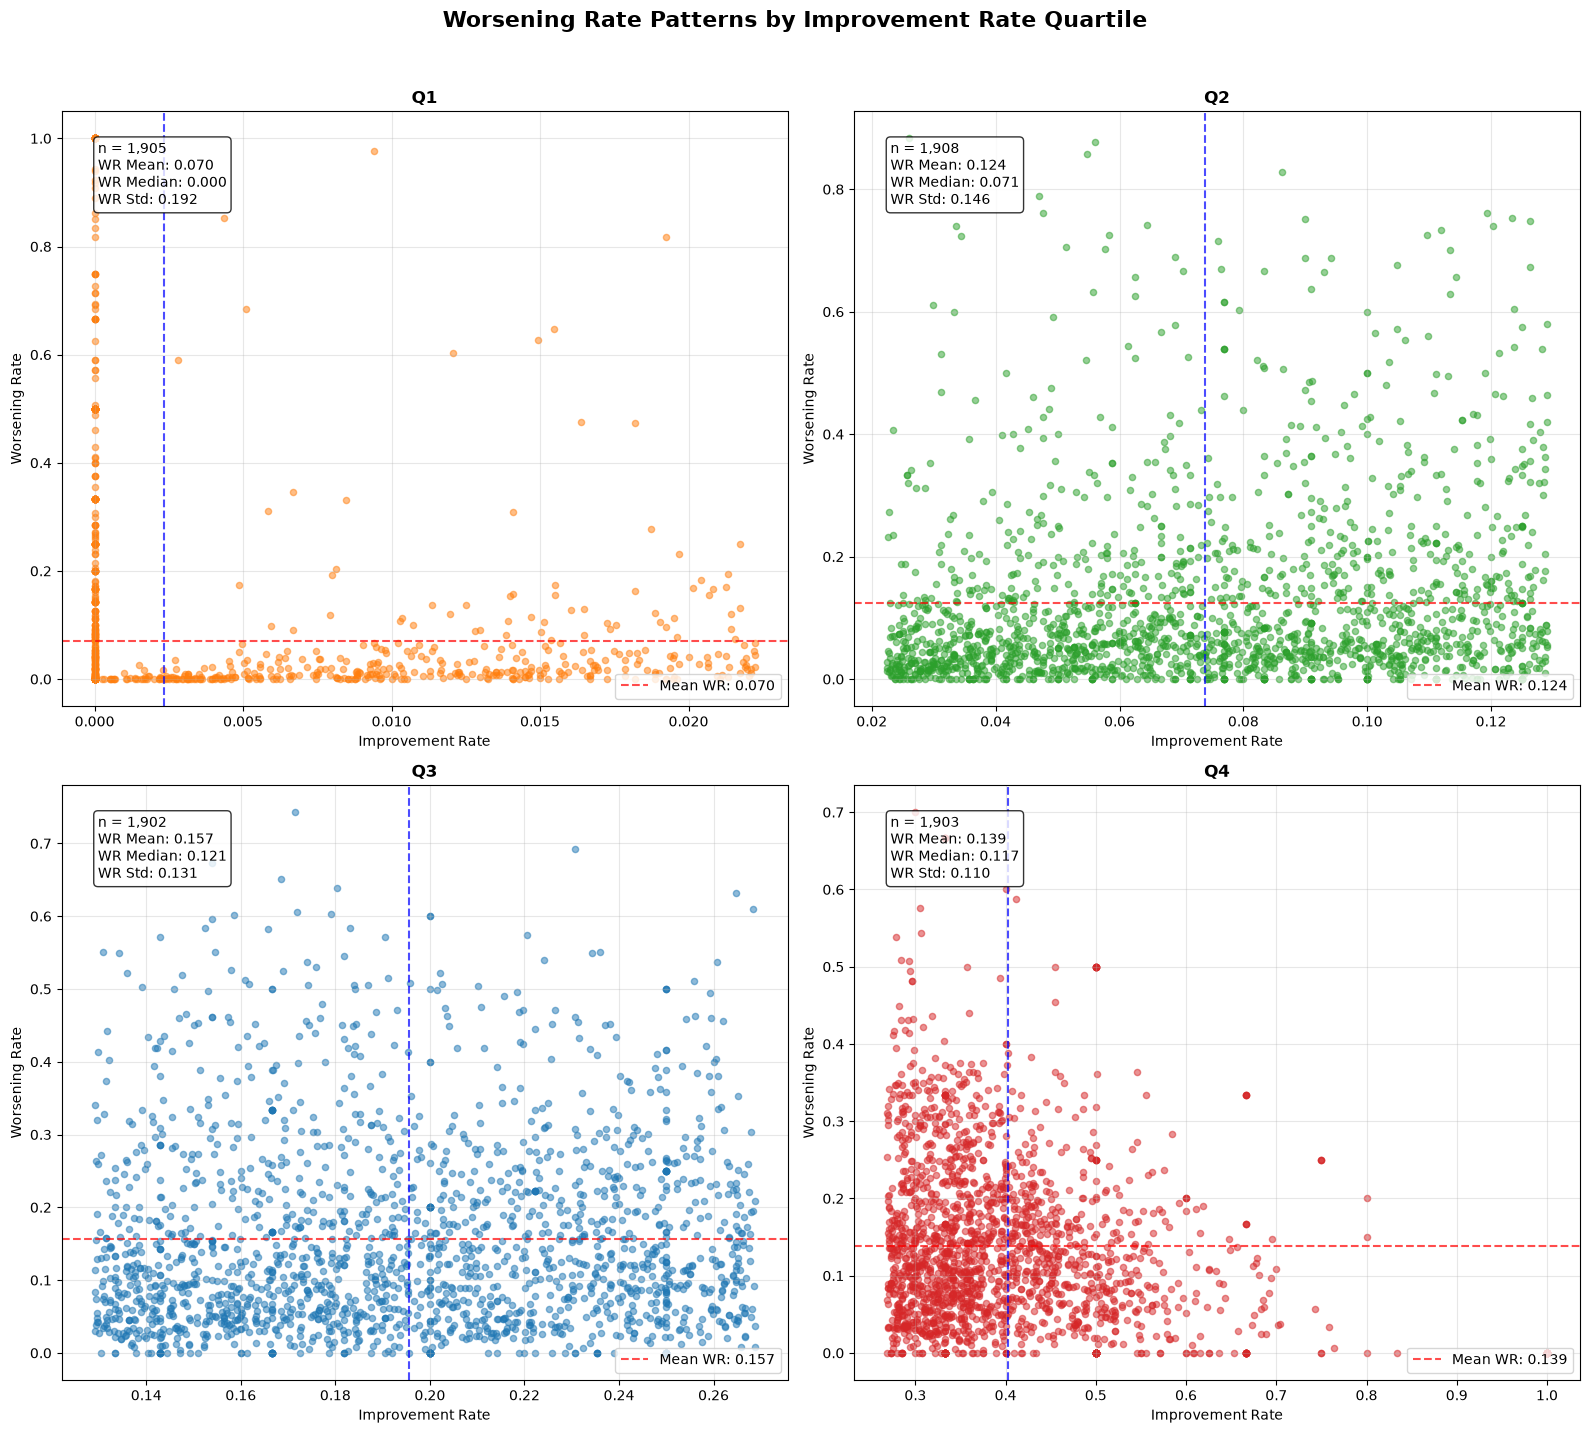

In [19]:
# Create quartile column for improvement_rate
cummulative_diff['improvement_quartile'] = pd.qcut(cummulative_diff['improvement_rate'], 
                                      q=4, 
                                      labels=['Q1', 'Q2', 'Q3', 'Q4'])
cummulative_diff['worsening_quartile'] = pd.qcut(cummulative_diff['worsening_rate'], 
                                      q=4, 
                                      labels=['Q1', 'Q2', 'Q3', 'Q4'])

print(cummulative_diff[['improvement_rate','improvement_quartile','avg_delta','delta_quartile']].head(30))
# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Color palette for each quartile
colors = ['#ff7f0e', '#2ca02c', '#1f77b4', '#d62728']
quartile_labels = ['Q1 (Lowest Improvement)', 'Q2', 'Q3', 'Q4 (Highest Improvement)']

for idx, (ax, quartile) in enumerate(zip(axes, sorted(cummulative_diff['improvement_quartile'].unique()))):
    # Subset data
    subset = cummulative_diff[cummulative_diff['improvement_quartile'] == quartile]
    
    # Scatter plot
    ax.scatter(subset['improvement_rate'], subset['worsening_rate'], 
               alpha=0.5, s=20, color=colors[idx])
    
    # Add mean lines
    ax.axhline(y=subset['worsening_rate'].mean(), 
               color='red', linestyle='--', alpha=0.7, 
               label=f'Mean WR: {subset["worsening_rate"].mean():.3f}')
    ax.axvline(x=subset['improvement_rate'].mean(), 
               color='blue', linestyle='--', alpha=0.7)
    
    # Add statistics
    ax.text(0.05, 0.95, 
            f'n = {len(subset):,}\n'
            f'WR Mean: {subset["worsening_rate"].mean():.3f}\n'
            f'WR Median: {subset["worsening_rate"].median():.3f}\n'
            f'WR Std: {subset["worsening_rate"].std():.3f}',
            transform=ax.transAxes,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title(f'{quartile}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Improvement Rate')
    ax.set_ylabel('Worsening Rate')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right')

plt.suptitle('Worsening Rate Patterns by Improvement Rate Quartile', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
delta_zero=cummulative_diff[cummulative_diff['improvement_rate']==0 &( cummulative_diff['worsening_rate']==0)]
print(f"Number of rows with both improvement_rate and worsening_rate equal to zero: {len(delta_zero)}")

delta_positive=cummulative_diff[(cummulative_diff['delta_quartile']=='Q4')&
                                (cummulative_diff['worsening_quartile']=='Q4')]
print(f"Positive Delta :{len(delta_positive)}")

delta_n=cummulative_diff[(cummulative_diff['improvement_quartile'].isin(['Q4']))
                          &(cummulative_diff['delta_quartile'].isin(['Q1']))]
print(f"Negative Delta :{len(delta_n)}")


Number of rows with both improvement_rate and worsening_rate equal to zero: 1496
Positive Delta :1300
Negative Delta :1014


In [21]:
#now we want to check coverage of kcs 
def get_unique_kc_ids(df, column='kc_ids'):
    # Parse strings to lists
    parsed = df[column].apply(ast.literal_eval)
    
    # Explode and get unique values
    exploded = parsed.explode()
    unique_kcs = exploded.dropna().unique()
    
    return sorted(unique_kcs)

#get all the unique kcs from cummulative diff
all_kcs = get_unique_kc_ids(cummulative_diff)
#get all kcs in delta categories
zero_delta_kcs=get_unique_kc_ids(delta_zero)
positive_delta_kcs=get_unique_kc_ids(delta_positive)
negative_delta_kcs=get_unique_kc_ids(delta_n)

print(f"Total unique KCs: {len(all_kcs)}")
print(f"Unique KCs with zero delta: {len(zero_delta_kcs)}")
print(f"Unique KCs with positive delta: {len(positive_delta_kcs)}")
print(f"Unique KCs with negative delta: {len(negative_delta_kcs)}")
print(f"KCs common between positive and negative delta: {len(set(positive_delta_kcs).intersection(set(negative_delta_kcs)))}")
print(f"KCs common between positive and zero delta: {len(set(positive_delta_kcs).intersection(set(zero_delta_kcs)))}")
print(f"KCs common between negative and zero delta: {len(set(negative_delta_kcs).intersection(set(zero_delta_kcs)))}")
print(f"KCs common between all three categories: {len(set(positive_delta_kcs).intersection(set(negative_delta_kcs)).intersection(set(zero_delta_kcs)))}")


Total unique KCs: 865
Unique KCs with zero delta: 671
Unique KCs with positive delta: 307
Unique KCs with negative delta: 198
KCs common between positive and negative delta: 181
KCs common between positive and zero delta: 259
KCs common between negative and zero delta: 171
KCs common between all three categories: 160


In [22]:
pos_n=set(positive_delta_kcs).intersection(set(negative_delta_kcs))
pos_zero=set(positive_delta_kcs).intersection(set(zero_delta_kcs))
n_zero=set(negative_delta_kcs).intersection(set(zero_delta_kcs))
all_three=set(positive_delta_kcs).intersection(set(negative_delta_kcs)).intersection(set(zero_delta_kcs))

cummulative_diff['kc_ids_parsed'] = cummulative_diff['kc_ids'].apply(ast.literal_eval)

# Count rows containing each KC in one go
counts = {}
for kc in all_three:
    counts[kc] = cummulative_diff['kc_ids_parsed'].apply(lambda x: kc in x).sum()

# Convert to DataFrame
counts_df = pd.DataFrame(list(counts.items()), columns=['kc_id', 'row_count'])
counts_df = counts_df.sort_values('row_count', ascending=False)

print(counts_df)
print(f"total questions covered by all three categories: {counts_df['row_count'].sum()}")

     kc_id  row_count
38      78        140
7       18        138
28      57        123
64     138        108
26      55        106
..     ...        ...
17     545          7
55     626          7
21     548          6
42     598          6
129    793          2

[160 rows x 2 columns]
total questions covered by all three categories: 5705


## Practice Effect Analysis

<Figure size 1200x600 with 0 Axes>

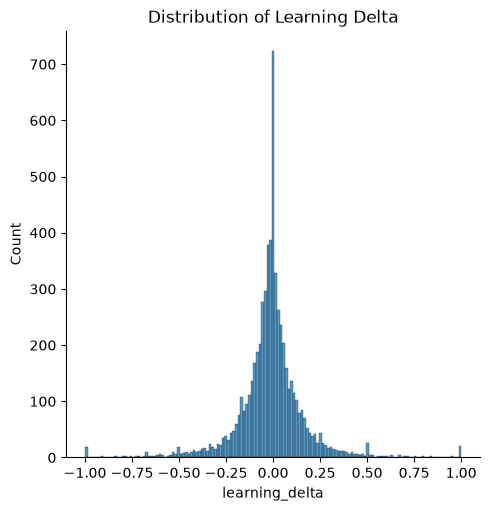

In [9]:
#lets check on the dist of learning_delta
plt.figure(figsize=(12,6))
sns.displot(chronological_delta['learning_delta'],kind='hist')
plt.title('Distribution of Learning Delta')
plt.show()

In [36]:
chronological_delta['learning_quartile'] = pd.qcut(chronological_delta['learning_delta'], 
                                      q=4, 
                                      labels=['Q1', 'Q2', 'Q3', 'Q4'])

delta_n_learning=pd.merge(delta_n,chronological_delta,on='questions',how='left')
delta_positive_learning=pd.merge(delta_positive,chronological_delta,on='questions',how='left')
delta_zero_learning=pd.merge(delta_zero,chronological_delta,on='questions',how='left')



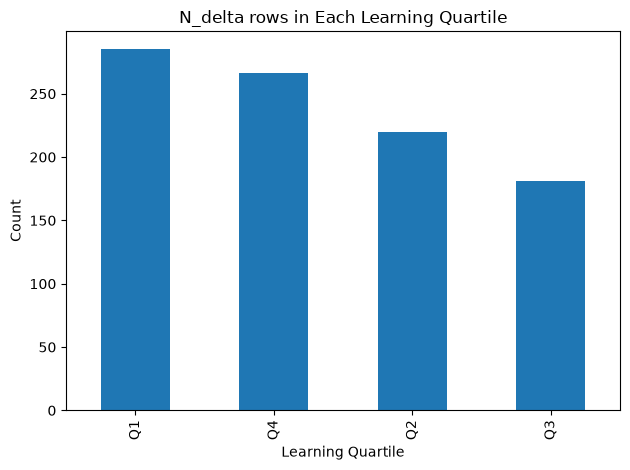

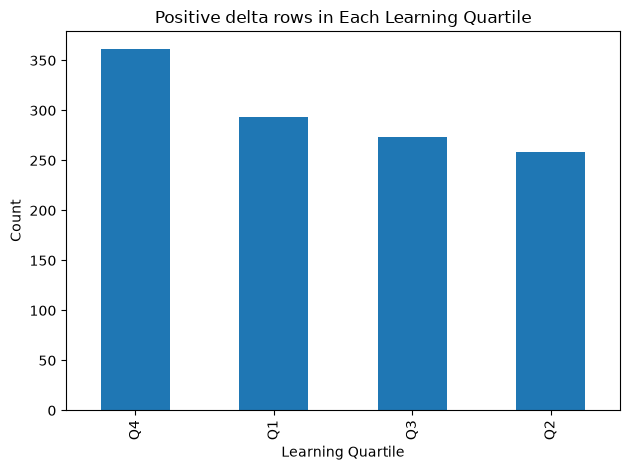

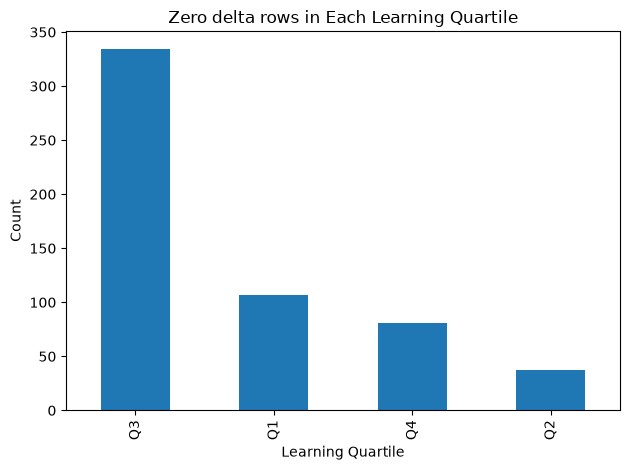

In [39]:
delta_n_learning['learning_quartile'].value_counts().plot(kind='bar')
plt.title('N_delta rows in Each Learning Quartile')
plt.xlabel('Learning Quartile')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

delta_positive_learning['learning_quartile'].value_counts().plot(kind='bar')
plt.title('Positive delta rows in Each Learning Quartile')
plt.xlabel('Learning Quartile')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

delta_zero_learning['learning_quartile'].value_counts().plot(kind='bar')
plt.title('Zero delta rows in Each Learning Quartile')
plt.xlabel('Learning Quartile')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [40]:
delta_n_learning.to_csv('level_1_qs.csv',index=False)
delta_zero_learning.to_csv('level_2_qs.csv',index=False)
delta_positive_learning.to_csv('level_3_qs.csv',index=False)

In [26]:

# Add a column to identify which group each row belongs to
delta_n_learning['group'] = 'Delta N'
delta_positive_learning['group'] = 'Delta Positive'
delta_zero_learning['group'] = 'Delta Zero'

# Combine all three dataframes
combined = pd.concat([delta_n_learning, delta_positive_learning, delta_zero_learning], ignore_index=True)


C:\Users\Hatem\AppData\Local\Temp\ipykernel_22368\3703092806.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined, x='group', y='learning_delta',
e:\projects\SprintLabData\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 43.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
e:\projects\SprintLabData\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 39.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


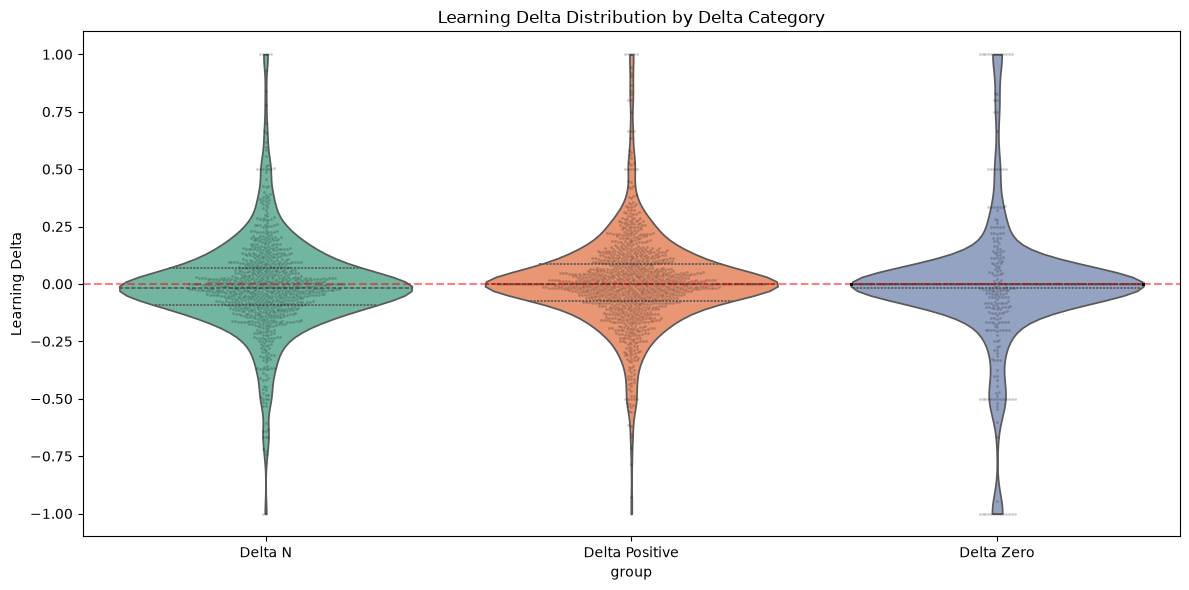

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

# Add group labels
delta_n_learning['group'] = 'Delta N'
delta_positive_learning['group'] = 'Delta Positive'
delta_zero_learning['group'] = 'Delta Zero'

combined = pd.concat([delta_n_learning, delta_positive_learning, delta_zero_learning], ignore_index=True)

sns.violinplot(data=combined, x='group', y='learning_delta', 
               palette='Set2', inner='quartile', cut=0)
sns.swarmplot(data=combined, x='group', y='learning_delta', 
              alpha=0.2, size=2, color='black')

ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('Learning Delta Distribution by Delta Category')
ax.set_ylabel('Learning Delta')
plt.tight_layout()
plt.show()

In [10]:
chronological_delta=pd.merge(chronological_delta,cummulative_diff,on='questions',how='left')

#calculate quartiles of delta and improvement rate


print(chronological_delta.head())


   questions  before_error  after_error  learning_delta  improvement_rate_x  \
0          0      0.583333     0.524213       -0.059120            0.000000   
1          1      0.116141     0.040073       -0.076068            0.055027   
2          2      0.216514     0.366573        0.150059            0.073272   
3          3      0.227585     0.427743        0.200158            0.036189   
4          4           NaN          NaN             NaN            0.000000   

   avg_delta  median_delta  improvement_rate_y  worsening_rate  \
0  -0.312805         -0.25            0.202418        0.010748   
1   0.200446          0.00            0.038043        0.144701   
2  -0.069883          0.00            0.247005        0.105530   
3  -0.152723          0.00            0.283637        0.054748   
4        NaN           NaN            0.000000        0.000000   

   n_observations  ...  kc_ids  attempted  correct  wrong  error_rate  \
0             843  ...     [0]     2233.0   2023.0  210

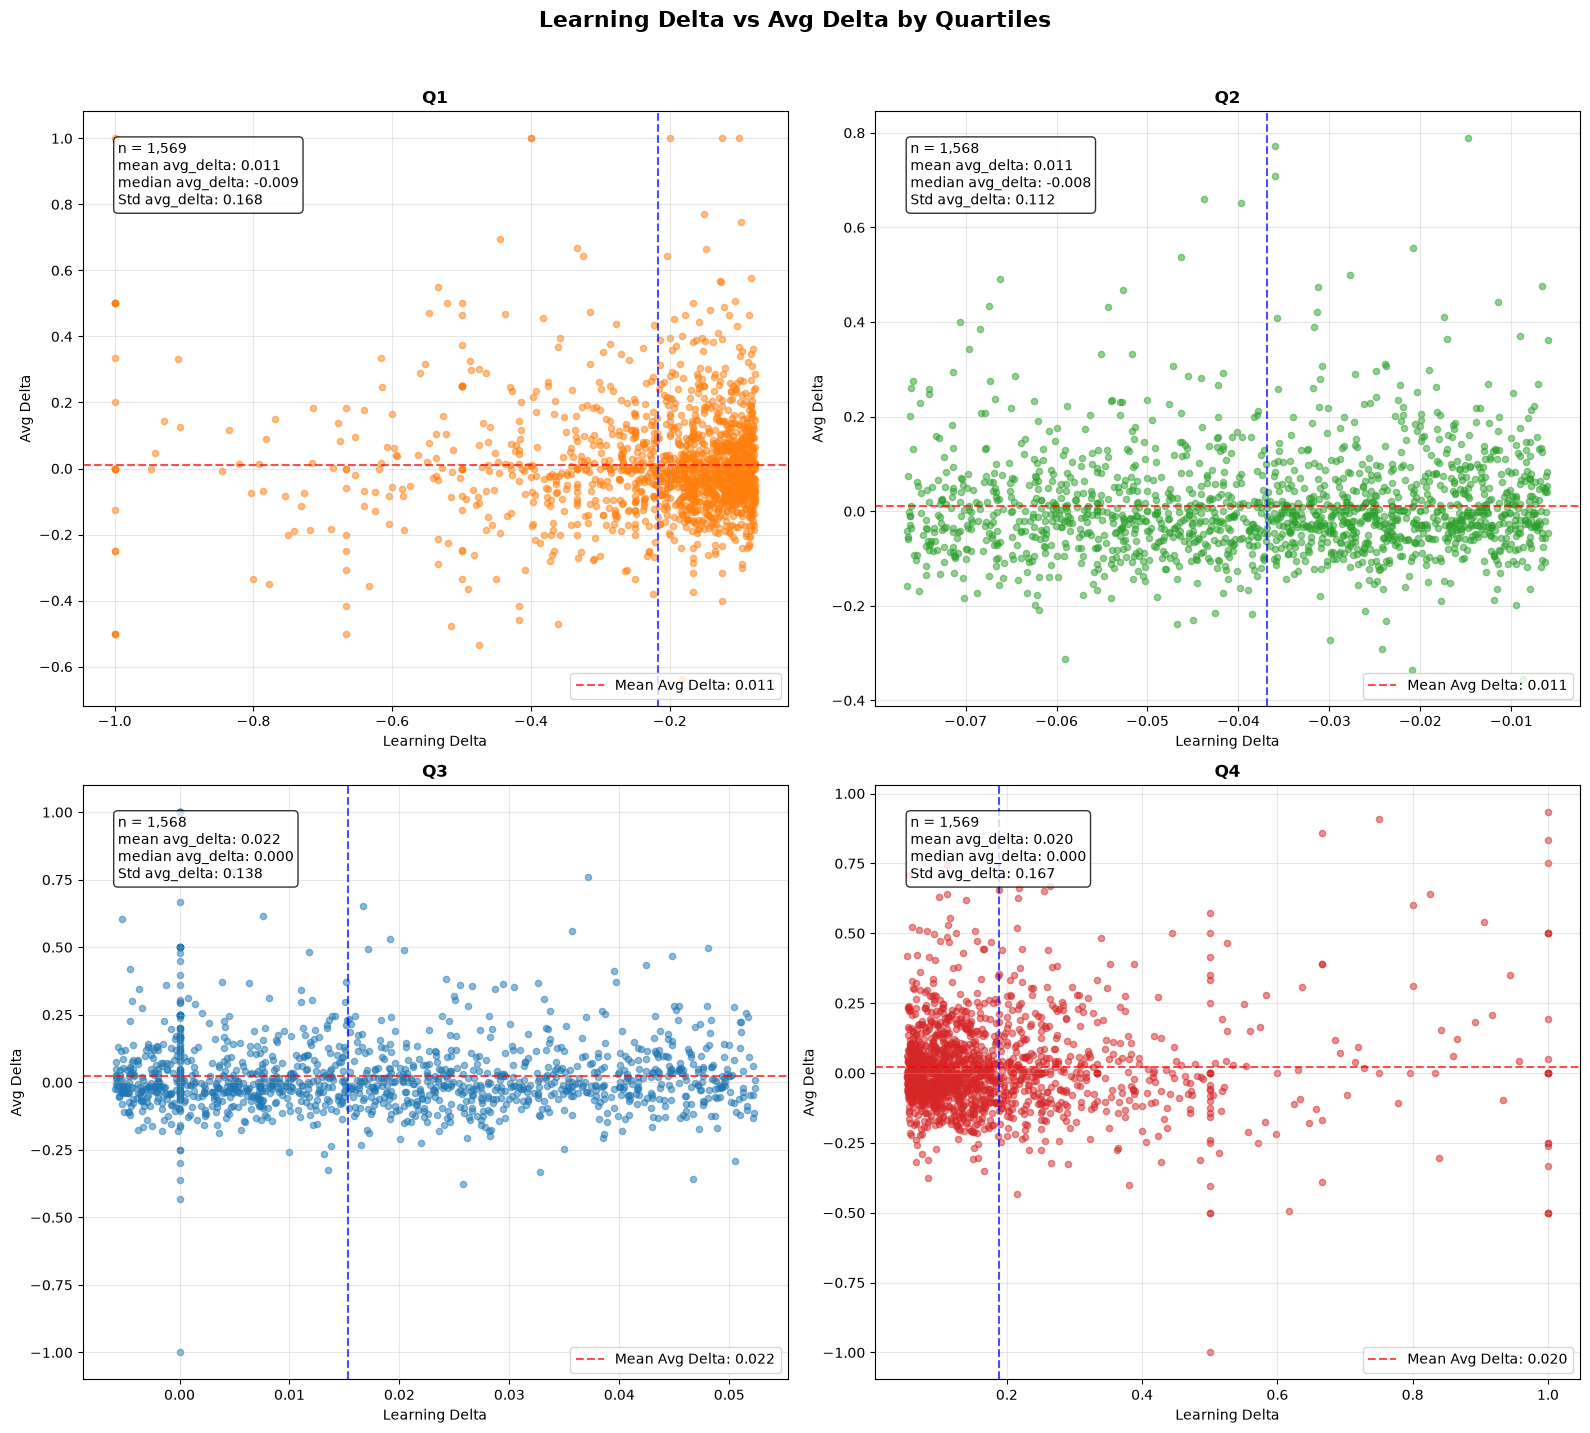

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Color palette for each quartile
colors = ['#ff7f0e', '#2ca02c', '#1f77b4', '#d62728']
quartile_labels = ['Q1 (Lowest Learning Delta)', 'Q2', 'Q3', 'Q4 (Highest Learning Delta)']

for idx, (ax, quartile) in enumerate(zip(axes, ['Q1', 'Q2', 'Q3', 'Q4'])):
    # Subset data
    subset = chronological_delta[chronological_delta['learning_quartile'] == quartile]
    
    # Scatter plot
    ax.scatter(subset['learning_delta'], subset['avg_delta'], 
               alpha=0.5, s=20, color=colors[idx])
    
    # Add mean lines
    ax.axhline(y=subset['avg_delta'].mean(), 
               color='red', linestyle='--', alpha=0.7, 
               label=f'Mean Avg Delta: {subset["avg_delta"].mean():.3f}')
    ax.axvline(x=subset['learning_delta'].mean(), 
               color='blue', linestyle='--', alpha=0.7)
    
    # Add statistics
    ax.text(0.05, 0.95, 
            f'n = {len(subset):,}\n'
            f'mean avg_delta: {subset["avg_delta"].mean():.3f}\n'
            f'median avg_delta: {subset["avg_delta"].median():.3f}\n'
            f'Std avg_delta: {subset["avg_delta"].std():.3f}',
            transform=ax.transAxes,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title(f'{quartile}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Learning Delta')
    ax.set_ylabel('Avg Delta')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right')

plt.suptitle('Learning Delta vs Avg Delta by Quartiles', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Textual Feature Analysis

In [55]:
textual_features=pd.read_csv(os.getenv("question_text_features"))
diff=pd.read_csv(os.getenv('differentiation_cumulative'))

textual_features=pd.merge(
    left=textual_features,
    right=diff,
    left_on='question_id',
    right_on='questions',
    how='left'
)
#drop question_id_x and y 
textual_features = textual_features.drop(columns=['question_id_x', 'question_id_y'], errors='ignore')
level_1=pd.read_csv(os.getenv("level_1"))
level_2=pd.read_csv(os.getenv("level_2"))
level_3=pd.read_csv(os.getenv("level_3"))

level_1_qs = set(level_1['questions'].tolist())
level_2_qs = set(level_2['questions'].tolist())
level_3_qs = set(level_3['questions'].tolist())

In [56]:
mask = textual_features['question_id'].isin(level_1_qs)
textual_features.loc[mask, 'level'] = 'level_1'

mask = textual_features['question_id'].isin(level_2_qs)
textual_features.loc[mask, 'level'] = 'level_2'

mask = textual_features['question_id'].isin(level_3_qs)
textual_features.loc[mask, 'level'] = 'level_3'

print(textual_features.head(5))

   question_id  index                                            content  \
0            0      0  学校有舞蹈，唱歌、围棋、绘画四种兴趣班． 小宇、小明、小丽三个小朋友准备报名，每人只能报一个...   
1            1      1  书架上有 $$2$$ 本不同的英语书，$$4$$ 本不同的语文书，$$3$$ 本不同的数学书...   
2            2      2  用$$5$$种不同的颜色给下面的图形染色，要求相邻的区域（有公共边的两区域称为相邻）染成不同...   
3            3      3  用四种颜色去涂如图所示的三块区域，要求相邻的区域涂不同的颜色，那么共有种不同的涂法.\n q...   
4            4      4  按下表给出的词造句，每句必须包括一个人、一个交通工具，以及一个目的地，请问可以造出个不同的句...   

                                           kc_routes       answer  \
0     ['拓展思维----计数模块----加乘原理----乘法原理----乘法原理里的其他类型']   ['$$24$$']   
1  ['拓展思维----计数模块----加乘原理----加乘原理综合', '拓展思维----计数...   ['$$26$$']   
2                 ['拓展思维----计数模块----加乘原理----染色计数问题']  ['$$180$$']   
3                 ['拓展思维----计数模块----加乘原理----染色计数问题']   ['$$24$$']   
4         ['拓展思维----计数模块----加乘原理----乘法原理----物体数量组合']   ['$$27$$']   

                                            analysis type options  kc_ids  \
0  小宇先选，有$$4$$种，接下来小明选，有$$3$$种，最后小丽选，有$$2$$种，所以一共..

<Figure size 1200x600 with 0 Axes>

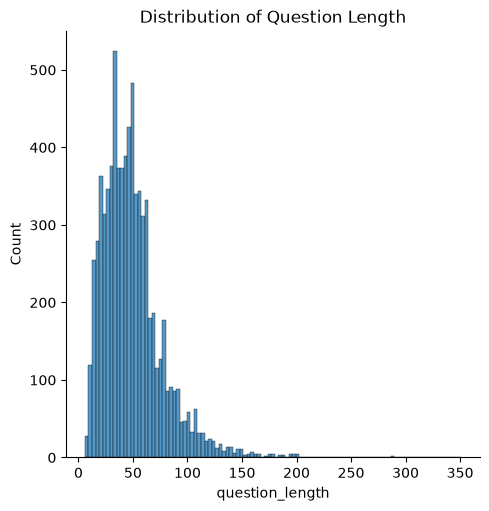

<Figure size 1200x600 with 0 Axes>

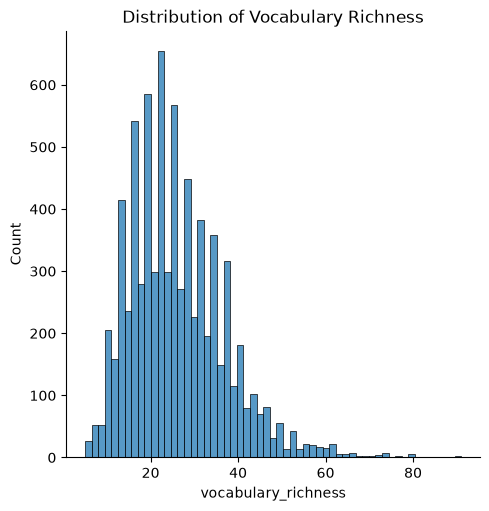

<Figure size 1200x600 with 0 Axes>

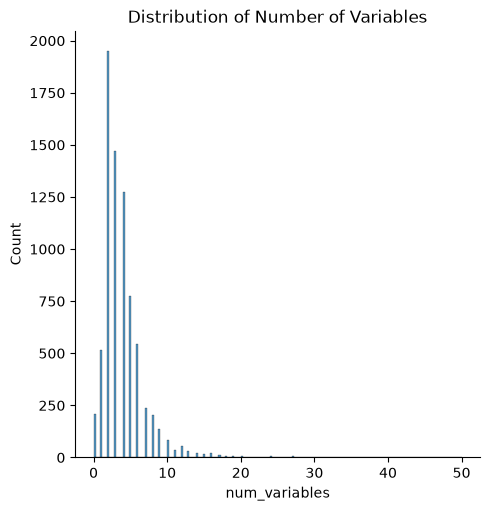

<Figure size 1200x600 with 0 Axes>

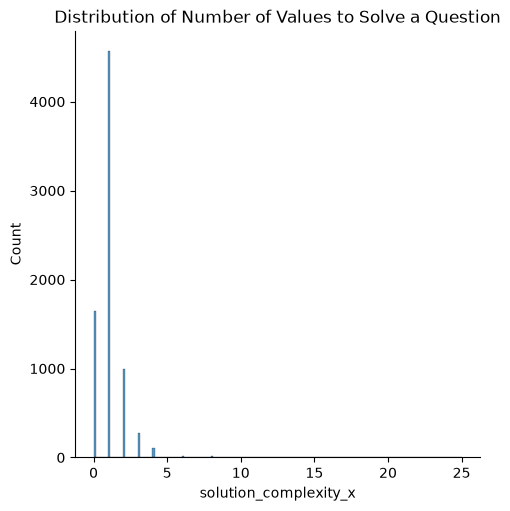

<Figure size 1200x600 with 0 Axes>

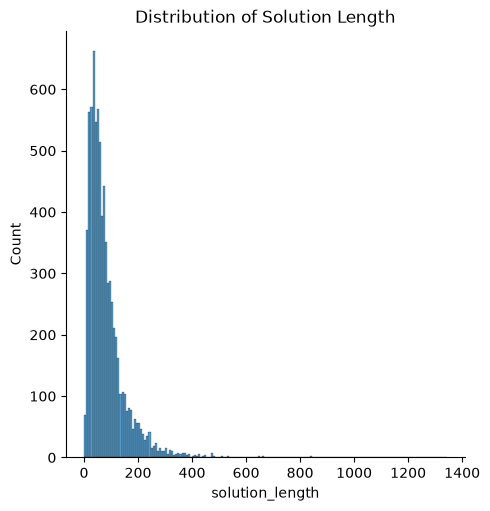

<Figure size 1200x600 with 0 Axes>

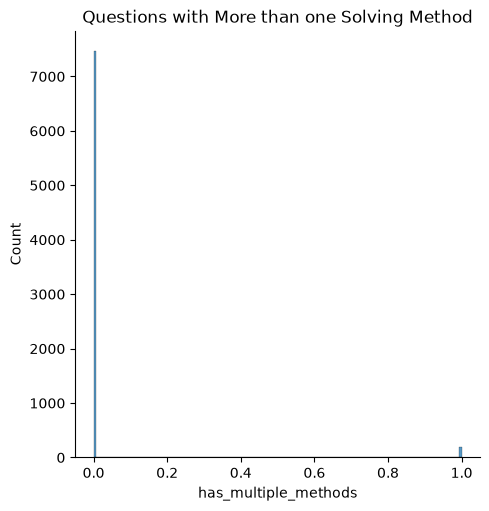

<Figure size 1200x600 with 0 Axes>

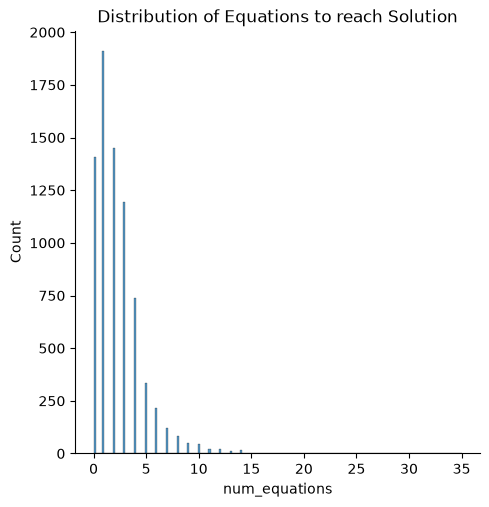

<Figure size 1200x600 with 0 Axes>

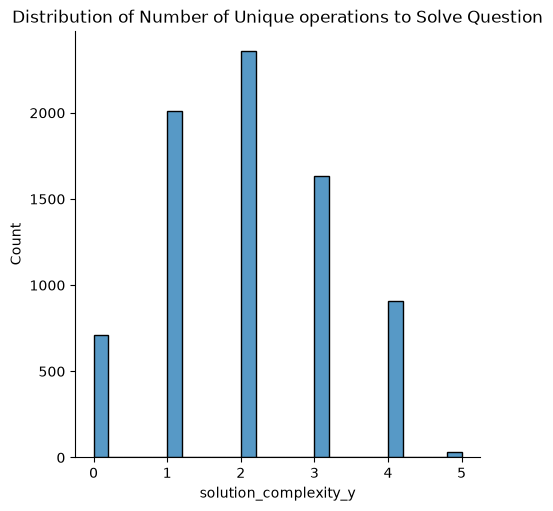

In [ ]:
#distributions of textual features

#Question Features
plt.figure(figsize=(12,6))
sns.displot(textual_features['question_length'],kind='hist')
plt.title('Distribution of Question Length')
plt.show()

plt.figure(figsize=(12,6))
sns.displot(textual_features['vocabulary_richness'],kind='hist')
plt.title('Distribution of Vocabulary Richness')
plt.show()

plt.figure(figsize=(12,6))
sns.displot(textual_features['num_variables'],kind='hist')
plt.title('Distribution of Number of Variables')
plt.show()

plt.figure(figsize=(12,6))
sns.displot(textual_features['solution_complexity_x'],kind='hist')
plt.title('Distribution of Number of Values to Solve a Question')
plt.show()

#Solution Features
plt.figure(figsize=(12,6))
sns.displot(textual_features['solution_length'],kind='hist')
plt.title('Distribution of Solution Length')
plt.show()

plt.figure(figsize=(12,6))
sns.displot(textual_features['has_multiple_methods'],kind='hist')
plt.title('Questions with More than one Solving Method')
plt.show()

plt.figure(figsize=(12,6))
sns.displot(textual_features['num_equations'],kind='hist')
plt.title('Distribution of Equations to reach Solution')
plt.show()

plt.figure(figsize=(12,6))
sns.displot(textual_features['solution_complexity_y'],kind='hist')
plt.title('Distribution of Number of Unique operations to Solve Question')
plt.show()


C:\Users\Hatem\AppData\Local\Temp\ipykernel_22368\2181478467.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quartile_stats = textual_features.groupby('avg_delta_quartile')[textual_features_list].agg(
C:\Users\Hatem\AppData\Local\Temp\ipykernel_22368\2181478467.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comparison_df = textual_features.groupby('avg_delta_quartile')[textual_features_list].mean().T


=== Textual Features by avg_delta Quartile ===
                   vocabulary_richness                      num_variables  \
                                  mean median     std count          mean   
avg_delta_quartile                                                          
Q1                              25.857   24.0  10.459  1760         3.590   
Q2                              25.868   24.0  10.964  2248         3.881   
Q3                              26.136   24.5  10.800  1270         3.952   
Q4                              27.156   25.0  11.069  1759         4.225   

                                       solution_complexity_x         ...  \
                   median    std count                  mean median  ...   
avg_delta_quartile                                                   ...   
Q1                    3.0  2.581  1760                 0.969    1.0  ...   
Q2                    3.0  3.106  2248                 1.019    1.0  ...   
Q3                    3.0  3.043 

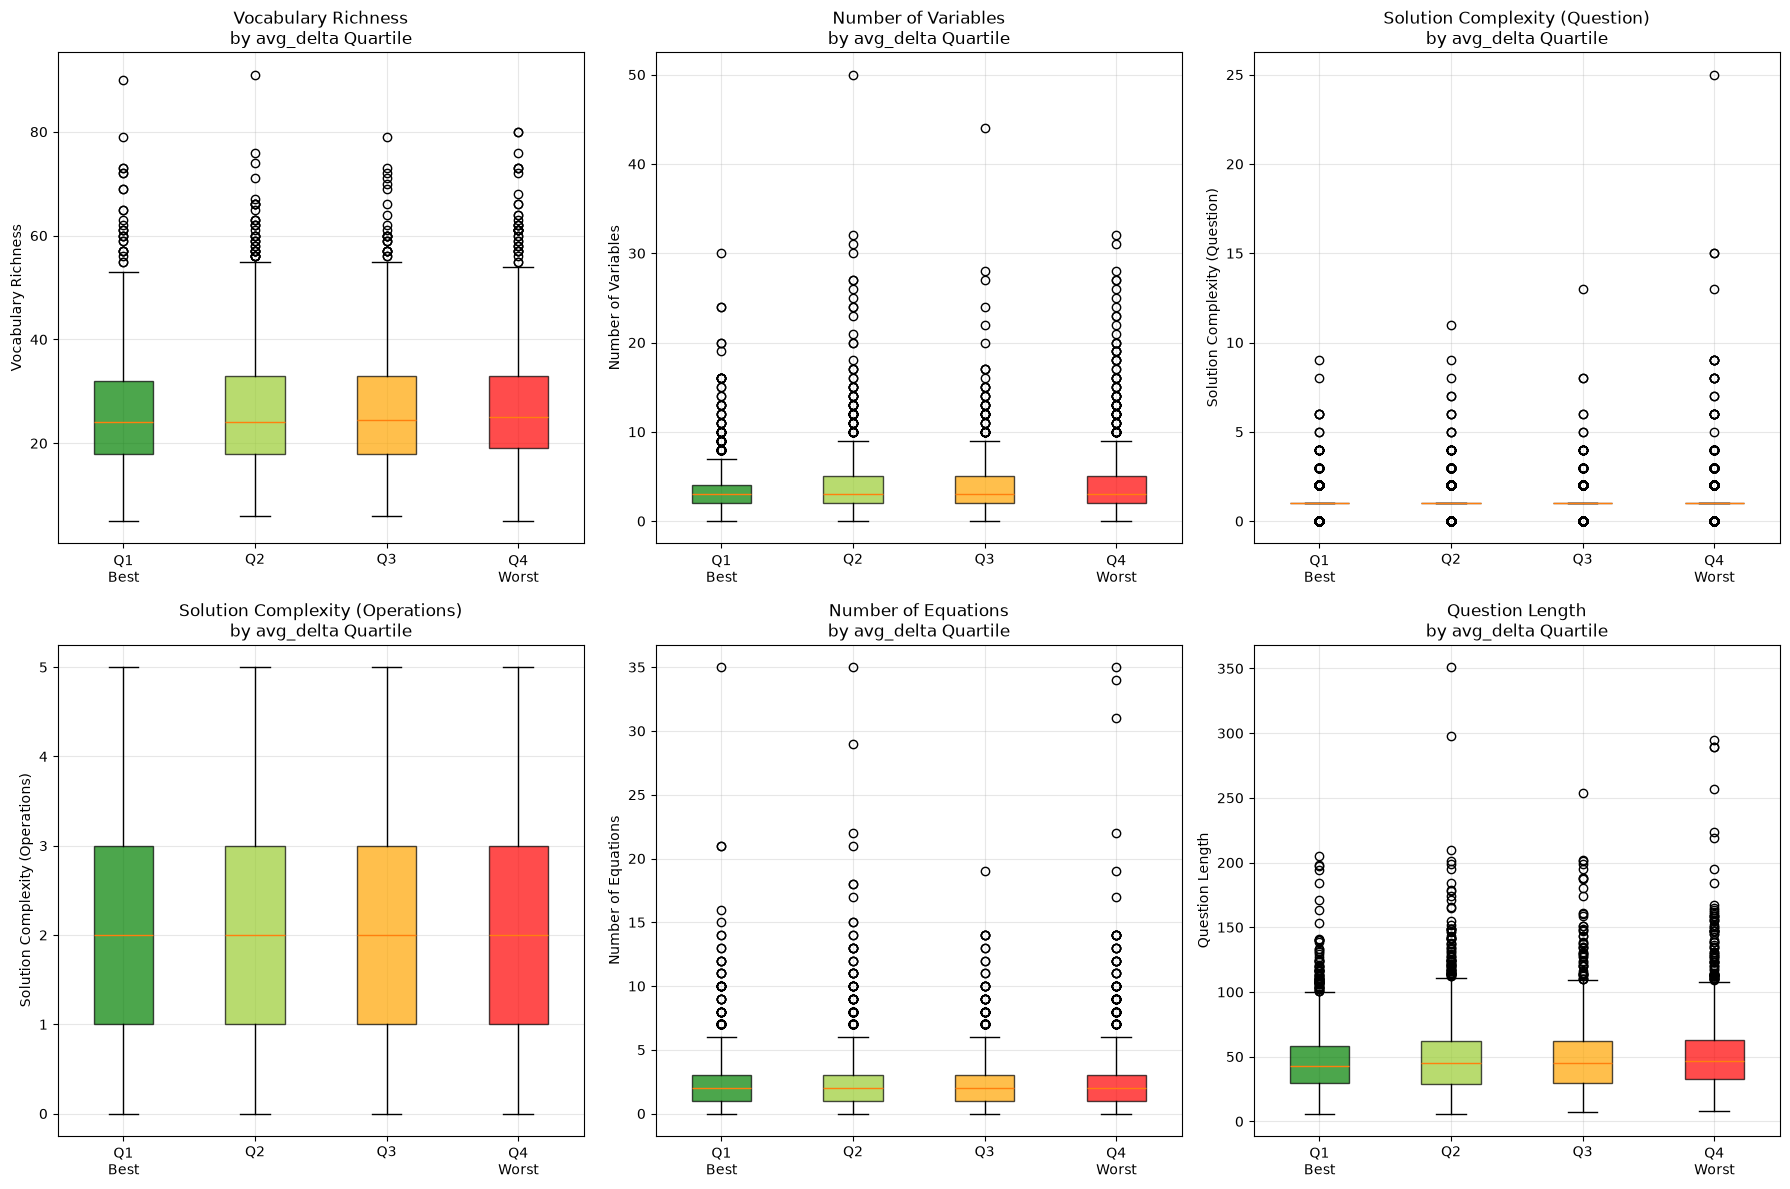


=== Correlation with avg_delta ===
avg_delta                1.000000
solution_complexity_x    0.088463
num_variables            0.078116
question_length          0.071864
solution_length          0.071745
solution_complexity_y    0.055065
vocabulary_richness      0.049346
num_equations            0.046091
num_clauses              0.028685
num_sentences            0.011548
num_solutions                 NaN
Name: avg_delta, dtype: float64

=== Features by Level and Quartile ===
                            vocabulary_richness  num_variables  \
level   avg_delta_quartile                                       
level_1 Q1                               26.236          3.505   
        Q2                                  NaN            NaN   
        Q3                                  NaN            NaN   
        Q4                                  NaN            NaN   
level_2 Q1                                  NaN            NaN   
        Q2                               26.475         

C:\Users\Hatem\AppData\Local\Temp\ipykernel_22368\2181478467.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  level_quartile_stats = textual_features.groupby(['level', 'avg_delta_quartile'])[


In [ ]:
# ============================================================
# STEP 1: Create quartiles based on avg_delta
# ============================================================

# Add quartile column
textual_features['avg_delta_quartile'] = pd.qcut(
    textual_features['avg_delta'], 
    q=4, 
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

# Or if you want numeric quartiles
textual_features['avg_delta_quartile_num'] = pd.qcut(
    textual_features['avg_delta'], 
    q=4, 
    labels=[1, 2, 3, 4]
)

# ============================================================
# STEP 2: Aggregate textual features by quartile
# ============================================================

# Define features to analyze
textual_features_list = [
    'vocabulary_richness', 
    'num_variables', 
    'solution_complexity_x',  # from question features
    'solution_complexity_y',  # from solution features (operations complexity)
    'num_equations',
    'question_length',
    'solution_length',
    'num_sentences',
    'num_clauses',
    'num_solutions'
]

# Group by quartile and calculate mean, median, std
quartile_stats = textual_features.groupby('avg_delta_quartile')[textual_features_list].agg(
    ['mean', 'median', 'std', 'count']
).round(3)

print("=== Textual Features by avg_delta Quartile ===")
print(quartile_stats)

# ============================================================
# STEP 3: Detailed comparison table
# ============================================================

# Create a comparison table showing how each feature changes across quartiles
comparison_df = textual_features.groupby('avg_delta_quartile')[textual_features_list].mean().T
comparison_df.columns = [f'Q{i+1}' for i in range(4)]

# Add the difference between Q1 and Q4
comparison_df['Q1_vs_Q4_diff'] = comparison_df['Q1'] - comparison_df['Q4']
comparison_df['Q1_vs_Q4_pct'] = ((comparison_df['Q1'] - comparison_df['Q4']) / comparison_df['Q4'] * 100).round(1)

print("\n=== Feature Comparison Across Quartiles ===")
print(comparison_df)

# ============================================================
# STEP 4: Visualize features by quartile
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

features_to_plot = [
    ('vocabulary_richness', 'Vocabulary Richness'),
    ('num_variables', 'Number of Variables'),
    ('solution_complexity_x', 'Solution Complexity (Question)'),
    ('solution_complexity_y', 'Solution Complexity (Operations)'),
    ('num_equations', 'Number of Equations'),
    ('question_length', 'Question Length')
]

for idx, (feature, label) in enumerate(features_to_plot):
    ax = axes[idx]
    
    # Box plot by quartile
    data = [textual_features[textual_features['avg_delta_quartile'] == q][feature].dropna() 
            for q in ['Q1', 'Q2', 'Q3', 'Q4']]
    bp = ax.boxplot(data, patch_artist=True)
    ax.set_xticklabels(['Q1\nBest', 'Q2', 'Q3', 'Q4\nWorst'])
    
    # Color the boxes
    colors = ['green', 'yellowgreen', 'orange', 'red']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f'{label}\nby avg_delta Quartile', fontsize=12)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('textual_features_by_quartile.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# STEP 5: Correlation with avg_delta
# ============================================================

print("\n=== Correlation with avg_delta ===")
correlations = textual_features[textual_features_list + ['avg_delta']].corr()['avg_delta'].sort_values(ascending=False)
print(correlations)

# ============================================================
# STEP 6: Summary by level and quartile
# ============================================================

if 'level' in textual_features.columns:
    level_quartile_stats = textual_features.groupby(['level', 'avg_delta_quartile'])[
        ['vocabulary_richness', 'num_variables', 'solution_complexity_x', 'num_equations']
    ].mean().round(3)
    
    print("\n=== Features by Level and Quartile ===")
    print(level_quartile_stats)

# ============================================================
# STEP 7: Save results
# ============================================================

# Save quartile statistics
quartile_stats.to_csv('textual_features_by_quartile.csv')

# Save comparison table
comparison_df.to_csv('textual_features_quartile_comparison.csv')

print("\n✅ Results saved to CSV files")